In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image
from pathlib import Path
import os

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
BASE_DIR = Path(__file__).resolve().parent

TRAIN_DIR = BASE_DIR / "data/intel-image-classification/seg_train/seg_train"
TEST_DIR = BASE_DIR / "data/intel-image-classification/seg_test/seg_test"
PRED_DIR = BASE_DIR / "data/intel-image-classification/seg_pred/seg_pred"

In [3]:
# dataset

def inspect_dir(path):
    for root, _, files in os.walk(path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg' '.png')):
                img = os.path.join(root, file)
                with Image.open(img) as i:
                    return i.size
    raise FileNotFoundError("Images do not exist")

print(inspect_dir(TRAIN_DIR))
print(inspect_dir(TEST_DIR))
print(inspect_dir(PRED_DIR))

(150, 150)
(150, 150)
(150, 150)


In [4]:
# define transforms

train_transform = v2.Compose([
    v2.Resize((150, 150)),
    v2.RandomRotation(degrees=10),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

test_transform = v2.Compose([
    v2.Resize((150, 150)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

train_transform_tl = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomRotation(degrees=10),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

test_transform_tl = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

display_transform = v2.Compose([
    v2.Resize((150, 150)),
])

In [5]:
# load the datasets - cnn

training_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform,
)
testing_dataset = ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

# dataloaders

training_loader = DataLoader(
    dataset=training_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=6
)
testing_loader = DataLoader(
    dataset=testing_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=6
)

In [6]:
# load the datasets - resnet

training_dataset_rn = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform_tl,
)
testing_dataset_rn = ImageFolder(
    root=TEST_DIR,
    transform=test_transform_tl
)

# dataloaders

training_loader_rn = DataLoader(
    dataset=training_dataset_rn,
    batch_size=64,
    shuffle=True,
    num_workers=6
)
testing_loader_rn = DataLoader(
    dataset=testing_dataset_rn,
    batch_size=64,
    shuffle=False,
    num_workers=6
)

In [7]:
# helper fn

import math

def give_size(existing, padding, kernel, stride):
    print(math.floor((existing + 2 * padding - kernel) / stride) + 1)

## Defining models

### 1. Previous best - CNN with dropout (p=0.5)

In [8]:
class CNN1_Dropout1(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(          # (1, 150, 150): (3, 150, 150)
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (32, 150, 150): (32, 75, 75)
            nn.Conv2d(            # (32, 75, 75): (64, 75, 75)
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (64, 75, 75): (64, 37, 37)
            nn.Conv2d(           # (64, 37, 37): (128, 37, 37(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
                    # (128, 37, 37): (128, 18, 18)
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*18*18, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

In [9]:
class CNN2_Dropout2(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(          # (1, 150, 150): (3, 150, 150)
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (32, 150, 150): (32, 75, 75)
            nn.Conv2d(            # (32, 75, 75): (64, 75, 75)
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # (64, 75, 75): (64, 37, 37)
            nn.Conv2d(           # (64, 37, 37): (128, 37, 37(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
                    # (128, 37, 37): (128, 18, 18)
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*18*18, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.6),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Dropout(p=0.6),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

In [6]:
class CNN3_ResNet(nn.Module):
    def __init__(self):
        super().__init__()

        # conv block 1
        # (3, 150, 150): (32, 75, 75)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, padding=1, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # conv block 2a
        # (32, 75, 75): (64, 75, 75)
        self.conv2ai = nn.Conv2d(32, 64, padding=1, kernel_size=3)
        self.relu2ai = nn.ReLU()
        # (64, 75): (64, 37, 37)
        self.conv2aii = nn.Conv2d(64, 64, padding=1, kernel_size=3)

        # conv block 2b
        # (32, 75, 75): (64, 37, 37)
        self.conv2b = nn.Conv2d(32, 64, kernel_size=1)

        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # conv block 3
        # (64, 37, 37): (128, 18, 18)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, padding=1, kernel_size=3)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*18*18, 1024),
            nn.ReLU(),
            # nn.Dropout(p=0.5),
            nn.Linear(1024, 128),
            nn.ReLU(),
            # nn.Dropout(p=0.5),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        # conv block 1
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # residual block
        identity = self.conv2b(x)

        out = self.conv2ai(x)
        out = self.relu2ai(out)

        out = self.conv2aii(out)

        # connecting the skip conn.n.
        out = out + identity


        out = self.relu2(out)
        out = self.pool2(out)

        out = self.conv3(out)
        out = self.relu3(out)
        out = self.pool3(out)

        x = self.clf(out)

        return x

In [33]:
from torchvision.models import resnet18

rn_model = resnet18(weights="DEFAULT")
rn_model.fc = nn.Linear(rn_model.fc.in_features, 6)

## Training

In [7]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

def validation(model, loader, criterion):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = outputs.argmax(1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

### 1. CNN1_Dropout1 — Shallow CNN + Dropout (p=0.5)

In [13]:
# loss, optimizer — CNN1_Dropout1

cnn1d1 = CNN1_Dropout1().to(device)

criterion_cnn1d1 = nn.CrossEntropyLoss()
optimizer_cnn1d1 = optim.Adam(params=cnn1d1.parameters(), lr=1e-3)

print(f"CNN1_Dropout1 trainable params: {sum(p.numel() for p in cnn1d1.parameters() if p.requires_grad):,}")

CNN1_Dropout1 trainable params: 42,693,574


In [14]:
# metrics storage — CNN1_Dropout1

training_acc_1   = []
training_loss_1  = []
validation_acc_1 = []
validation_loss_1 = []

In [15]:
# training loop — CNN1_Dropout1

epochs = 15

cnn1d1 = cnn1d1.to(device)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(cnn1d1, training_loader, criterion_cnn1d1, optimizer_cnn1d1)
    val_loss,   val_acc   = validation(cnn1d1, testing_loader, criterion_cnn1d1)

    training_loss_1.append(train_loss)
    training_acc_1.append(train_acc)
    validation_loss_1.append(val_loss)
    validation_acc_1.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

del cnn1d1, criterion_cnn1d1, optimizer_cnn1d1
torch.cuda.empty_cache()

Epoch  1 | Train Loss 1.0899 | Train Acc 0.5794 | Val Loss 0.8651 | Val Acc 0.6883
Epoch  2 | Train Loss 0.7372 | Train Acc 0.7339 | Val Loss 0.6030 | Val Acc 0.7863
Epoch  3 | Train Loss 0.6031 | Train Acc 0.7927 | Val Loss 0.5040 | Val Acc 0.8200
Epoch  4 | Train Loss 0.5274 | Train Acc 0.8177 | Val Loss 0.5041 | Val Acc 0.8270
Epoch  5 | Train Loss 0.4841 | Train Acc 0.8343 | Val Loss 0.4672 | Val Acc 0.8493
Epoch  6 | Train Loss 0.4498 | Train Acc 0.8473 | Val Loss 0.4332 | Val Acc 0.8560
Epoch  7 | Train Loss 0.4084 | Train Acc 0.8591 | Val Loss 0.4356 | Val Acc 0.8540
Epoch  8 | Train Loss 0.3900 | Train Acc 0.8653 | Val Loss 0.4343 | Val Acc 0.8480
Epoch  9 | Train Loss 0.3525 | Train Acc 0.8733 | Val Loss 0.4147 | Val Acc 0.8620
Epoch 10 | Train Loss 0.3361 | Train Acc 0.8811 | Val Loss 0.4492 | Val Acc 0.8593
Epoch 11 | Train Loss 0.3142 | Train Acc 0.8891 | Val Loss 0.4922 | Val Acc 0.8407
Epoch 12 | Train Loss 0.3119 | Train Acc 0.8897 | Val Loss 0.3866 | Val Acc 0.8747
Epoc

### 2. CNN2_Dropout2 — Shallow CNN + Dropout (p=0.6)

In [16]:
# loss, optimizer — CNN2_Dropout2

cnn2d2 = CNN2_Dropout2().to(device)

criterion_cnn2d2 = nn.CrossEntropyLoss()
optimizer_cnn2d2 = optim.Adam(params=cnn2d2.parameters(), lr=1e-3)

print(f"CNN2_Dropout2 trainable params: {sum(p.numel() for p in cnn2d2.parameters() if p.requires_grad):,}")

CNN2_Dropout2 trainable params: 42,693,574


In [17]:
# metrics storage — CNN2_Dropout2

training_acc_2   = []
training_loss_2  = []
validation_acc_2 = []
validation_loss_2 = []

In [18]:
# training loop — CNN2_Dropout2

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(cnn2d2, training_loader, criterion_cnn2d2, optimizer_cnn2d2)
    val_loss,   val_acc   = validation(cnn2d2, testing_loader, criterion_cnn2d2)

    training_loss_2.append(train_loss)
    training_acc_2.append(train_acc)
    validation_loss_2.append(val_loss)
    validation_acc_2.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

del cnn2d2, criterion_cnn2d2, optimizer_cnn2d2
torch.cuda.empty_cache()

Epoch  1 | Train Loss 1.1555 | Train Acc 0.5391 | Val Loss 0.8115 | Val Acc 0.6737
Epoch  2 | Train Loss 0.8145 | Train Acc 0.6997 | Val Loss 0.6314 | Val Acc 0.7753
Epoch  3 | Train Loss 0.6614 | Train Acc 0.7666 | Val Loss 0.5418 | Val Acc 0.8087
Epoch  4 | Train Loss 0.5676 | Train Acc 0.8103 | Val Loss 0.4925 | Val Acc 0.8247
Epoch  5 | Train Loss 0.5071 | Train Acc 0.8218 | Val Loss 0.4588 | Val Acc 0.8383
Epoch  6 | Train Loss 0.4614 | Train Acc 0.8392 | Val Loss 0.4316 | Val Acc 0.8477
Epoch  7 | Train Loss 0.4491 | Train Acc 0.8464 | Val Loss 0.4415 | Val Acc 0.8413
Epoch  8 | Train Loss 0.4201 | Train Acc 0.8561 | Val Loss 0.4662 | Val Acc 0.8383
Epoch  9 | Train Loss 0.4083 | Train Acc 0.8598 | Val Loss 0.4399 | Val Acc 0.8460
Epoch 10 | Train Loss 0.3813 | Train Acc 0.8657 | Val Loss 0.4649 | Val Acc 0.8380
Epoch 11 | Train Loss 0.3751 | Train Acc 0.8712 | Val Loss 0.4228 | Val Acc 0.8573
Epoch 12 | Train Loss 0.3493 | Train Acc 0.8793 | Val Loss 0.4158 | Val Acc 0.8633
Epoc

### 3. CNN3_ResNet — Custom residual block CNN

In [15]:
# loss, optimizer — CNN3_ResNet

cnn3_rn = CNN3_ResNet().to(device)

criterion_cnn3rn = nn.CrossEntropyLoss()
optimizer_cnn3rn = optim.Adam(params=cnn3_rn.parameters(), lr=1e-3)

print(f"CNN3_ResNet trainable params: {sum(p.numel() for p in cnn3_rn.parameters() if p.requires_grad):,}")

CNN3_ResNet trainable params: 42,732,614


In [14]:
# metrics storage — CNN3_ResNet

training_acc_3   = []
training_loss_3  = []
validation_acc_3 = []
validation_loss_3 = []

In [16]:
# training loop — CNN3_ResNet

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(cnn3_rn, training_loader, criterion_cnn3rn, optimizer_cnn3rn)
    val_loss,   val_acc   = validation(cnn3_rn, testing_loader, criterion_cnn3rn)

    training_loss_3.append(train_loss)
    training_acc_3.append(train_acc)
    validation_loss_3.append(val_loss)
    validation_acc_3.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

# del cnn3_rn, criterion_cnn3rn, optimizer_cnn3rn
# torch.cuda.empty_cache()

Epoch  1 | Train Loss 0.9250 | Train Acc 0.6440 | Val Loss 0.6735 | Val Acc 0.7560
Epoch  2 | Train Loss 0.5886 | Train Acc 0.7892 | Val Loss 0.5123 | Val Acc 0.8193
Epoch  3 | Train Loss 0.4777 | Train Acc 0.8284 | Val Loss 0.5171 | Val Acc 0.8120
Epoch  4 | Train Loss 0.4310 | Train Acc 0.8444 | Val Loss 0.4436 | Val Acc 0.8440
Epoch  5 | Train Loss 0.3709 | Train Acc 0.8678 | Val Loss 0.3935 | Val Acc 0.8603
Epoch  6 | Train Loss 0.3488 | Train Acc 0.8747 | Val Loss 0.4637 | Val Acc 0.8537
Epoch  7 | Train Loss 0.2967 | Train Acc 0.8937 | Val Loss 0.3969 | Val Acc 0.8553
Epoch  8 | Train Loss 0.2630 | Train Acc 0.9058 | Val Loss 0.4399 | Val Acc 0.8620
Epoch  9 | Train Loss 0.2348 | Train Acc 0.9143 | Val Loss 0.4213 | Val Acc 0.8627
Epoch 10 | Train Loss 0.1937 | Train Acc 0.9272 | Val Loss 0.4823 | Val Acc 0.8587
Epoch 11 | Train Loss 0.1784 | Train Acc 0.9364 | Val Loss 0.4761 | Val Acc 0.8580
Epoch 12 | Train Loss 0.1516 | Train Acc 0.9467 | Val Loss 0.4787 | Val Acc 0.8633
Epoc

### 4. ResNet18 — Pretrained (ImageNet weights) + Fine-tuned head

Uses the `_rn` dataloaders with 224×224 images (ResNet18's expected input size).  
Only the final `fc` layer was replaced with a 6-class linear head.

In [34]:
# loss, optimizer — ResNet18 fine-tuned
# Move to device BEFORE creating optimizer so param tensors are on GPU

rn_model = rn_model.to(device)

criterion_rn = nn.CrossEntropyLoss()
optimizer_rn = optim.Adam(params=rn_model.parameters(), lr=1e-4)  # lower LR for fine-tuning

print(f"ResNet18 trainable params: {sum(p.numel() for p in rn_model.parameters() if p.requires_grad):,}")

ResNet18 trainable params: 11,179,590


In [35]:
# metrics storage — ResNet18

training_acc_4   = []
training_loss_4  = []
validation_acc_4 = []
validation_loss_4 = []

In [36]:
# training loop — ResNet18 (uses _rn loaders: 224×224)

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(rn_model, training_loader_rn, criterion_rn, optimizer_rn)
    val_loss,   val_acc   = validation(rn_model, testing_loader_rn, criterion_rn)

    training_loss_4.append(train_loss)
    training_acc_4.append(train_acc)
    validation_loss_4.append(val_loss)
    validation_acc_4.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

# del rn_model, criterion_rn, optimizer_rn
# torch.cuda.empty_cache()

Epoch  1 | Train Loss 0.2919 | Train Acc 0.8971 | Val Loss 0.2036 | Val Acc 0.9237
Epoch  2 | Train Loss 0.1682 | Train Acc 0.9400 | Val Loss 0.2082 | Val Acc 0.9203
Epoch  3 | Train Loss 0.1315 | Train Acc 0.9520 | Val Loss 0.1885 | Val Acc 0.9313
Epoch  4 | Train Loss 0.1011 | Train Acc 0.9661 | Val Loss 0.2165 | Val Acc 0.9287
Epoch  5 | Train Loss 0.0754 | Train Acc 0.9746 | Val Loss 0.2359 | Val Acc 0.9243
Epoch  6 | Train Loss 0.0662 | Train Acc 0.9773 | Val Loss 0.2079 | Val Acc 0.9350
Epoch  7 | Train Loss 0.0501 | Train Acc 0.9831 | Val Loss 0.2061 | Val Acc 0.9340
Epoch  8 | Train Loss 0.0392 | Train Acc 0.9871 | Val Loss 0.2442 | Val Acc 0.9330
Epoch  9 | Train Loss 0.0416 | Train Acc 0.9865 | Val Loss 0.2415 | Val Acc 0.9353
Epoch 10 | Train Loss 0.0332 | Train Acc 0.9895 | Val Loss 0.2749 | Val Acc 0.9267
Epoch 11 | Train Loss 0.0267 | Train Acc 0.9903 | Val Loss 0.2557 | Val Acc 0.9340
Epoch 12 | Train Loss 0.0247 | Train Acc 0.9931 | Val Loss 0.2352 | Val Acc 0.9407
Epoc

## Comparison Plots (all 4 models)

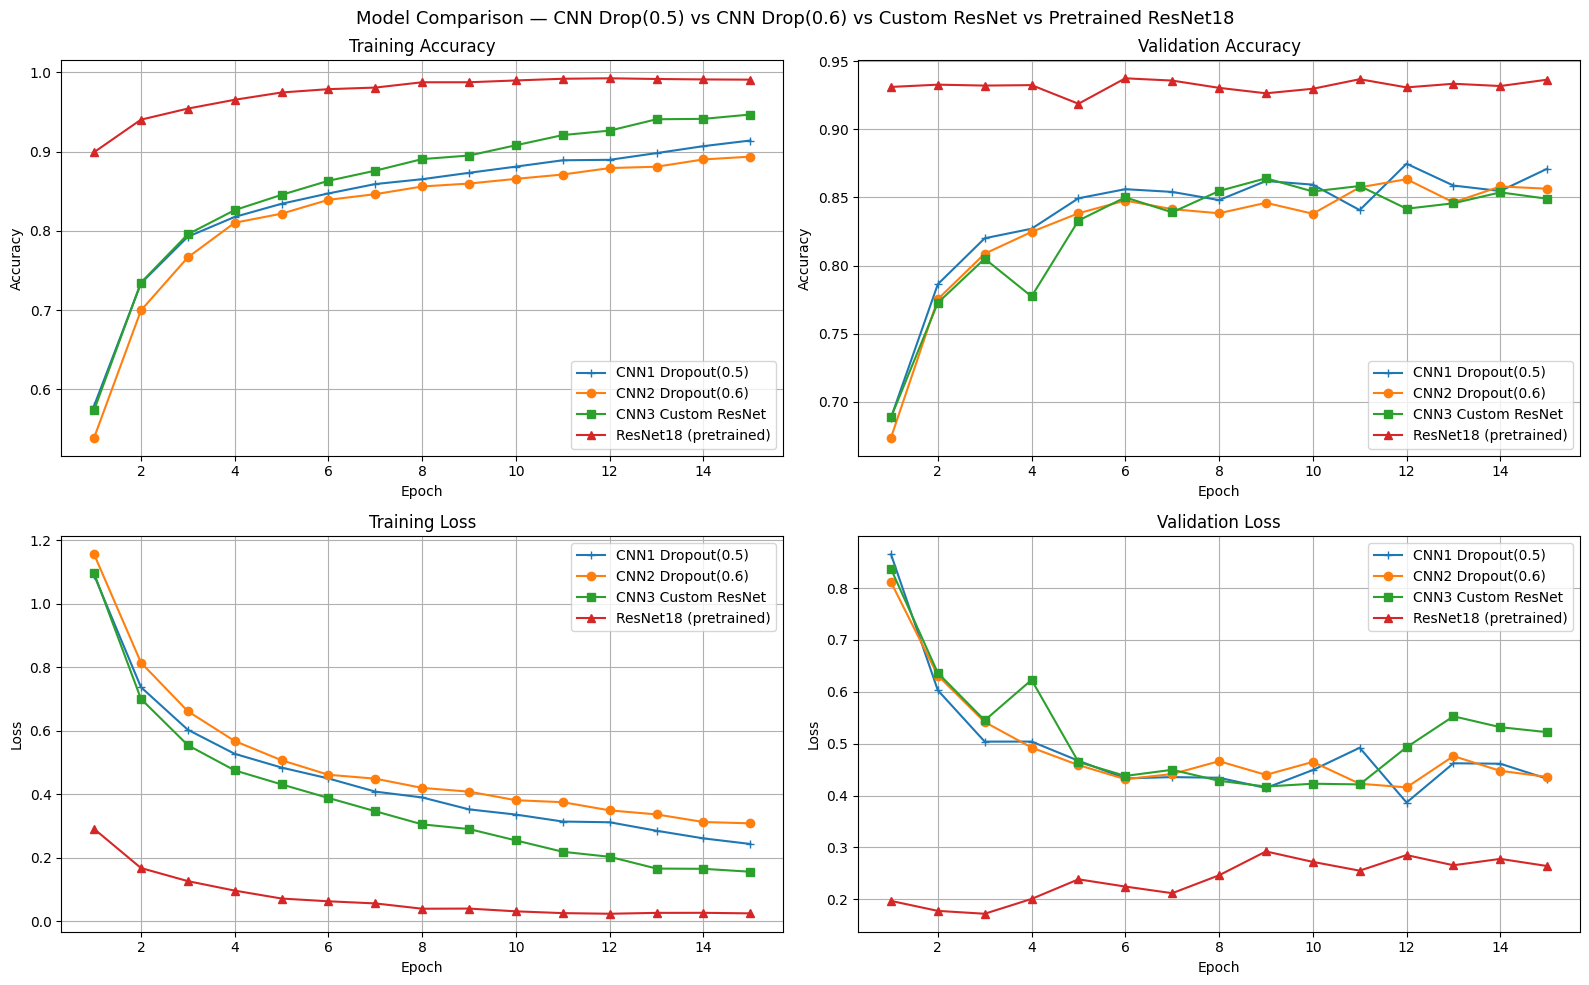

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "Model Comparison — CNN Drop(0.5) vs CNN Drop(0.6) vs Custom ResNet vs Pretrained ResNet18",
    fontsize=13
)

epochs_range = range(1, len(training_acc_1) + 1)

# Training Accuracy
ax = axes[0, 0]
ax.plot(epochs_range, training_acc_1, marker='+', label='CNN1 Dropout(0.5)')
ax.plot(epochs_range, training_acc_2, marker='o', label='CNN2 Dropout(0.6)')
ax.plot(epochs_range, training_acc_3, marker='s', label='CNN3 Custom ResNet')
ax.plot(epochs_range, training_acc_4, marker='^', label='ResNet18 (pretrained)')
ax.set_title('Training Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)

# Validation Accuracy
ax = axes[0, 1]
ax.plot(epochs_range, validation_acc_1, marker='+', label='CNN1 Dropout(0.5)')
ax.plot(epochs_range, validation_acc_2, marker='o', label='CNN2 Dropout(0.6)')
ax.plot(epochs_range, validation_acc_3, marker='s', label='CNN3 Custom ResNet')
ax.plot(epochs_range, validation_acc_4, marker='^', label='ResNet18 (pretrained)')
ax.set_title('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)

# Training Loss
ax = axes[1, 0]
ax.plot(epochs_range, training_loss_1, marker='+', label='CNN1 Dropout(0.5)')
ax.plot(epochs_range, training_loss_2, marker='o', label='CNN2 Dropout(0.6)')
ax.plot(epochs_range, training_loss_3, marker='s', label='CNN3 Custom ResNet')
ax.plot(epochs_range, training_loss_4, marker='^', label='ResNet18 (pretrained)')
ax.set_title('Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# Validation Loss
ax = axes[1, 1]
ax.plot(epochs_range, validation_loss_1, marker='+', label='CNN1 Dropout(0.5)')
ax.plot(epochs_range, validation_loss_2, marker='o', label='CNN2 Dropout(0.6)')
ax.plot(epochs_range, validation_loss_3, marker='s', label='CNN3 Custom ResNet')
ax.plot(epochs_range, validation_loss_4, marker='^', label='ResNet18 (pretrained)')
ax.set_title('Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# Final summary — best validation accuracy per model

models_summary = [
    ('CNN1_Dropout1 — Dropout(p=0.5)',         max(validation_acc_1)),
    ('CNN2_Dropout2 — Dropout(p=0.6)',         max(validation_acc_2)),
    ('CNN3_ResNet   — Custom residual block',  max(validation_acc_3)),
    ('ResNet18      — Pretrained fine-tuned',  max(validation_acc_4)),
]

print(f"{'Model':<50} {'Best Val Acc':>12}")
print("-" * 65)
for name, acc in models_summary:
    print(f"{name:<50} {acc:>12.4f}")

Model                                              Best Val Acc
-----------------------------------------------------------------
CNN1_Dropout1 — Dropout(p=0.5)                           0.8747
CNN2_Dropout2 — Dropout(p=0.6)                           0.8633
CNN3_ResNet   — Custom residual block                    0.8640
ResNet18      — Pretrained fine-tuned                    0.9373


In [17]:
# save the models' state dict

MODEL_DIR = BASE_DIR / "models"

cnn_path = MODEL_DIR / "torch05_cnn_skip_state_dict.pth"
rn_path = MODEL_DIR / "torch05_rn_state_dict.pth"

torch.save(rn_model.state_dict(),
            cnn_path)

torch.save(cnn3_rn.state_dict(),
           rn_path)